In [24]:
!pip install seaborn
!pip install xgboost
import pandas as pd
import matplotlib.pyplot as plt


In [25]:
data=pd.DataFrame()
X_train=pd.read_csv("data/train/train_tabular.csv")
X_train.head()


,flight_id,drone_id,model,motor_type,firmware_version,battery_capacity_mAh,max_payload_g,propeller_in,manufacture_batch,operator_region,flight_index,payload_g,ambient_temp_C,wind_speed_ms,flight_duration_min,avg_throttle,num_aggressive_maneuvers,cumulative_flight_hours,battery_cycles,failure_mode,failure_within_horizon
0,0,D1000,C,M3,v3.1,5200,900.0,11.0,3,east,1,69.2,18.75,15.63,14.85,0.341,0,16.44,25,none,0
1,1,D1000,C,M3,v3.1,5200,900.0,11.0,3,east,2,728.1,29.90,5.97,10.59,0.762,1,16.61,26,none,0
2,2,D1000,C,M3,v3.1,5200,900.0,11.0,3,east,3,868.3,30.96,12.01,18.62,0.928,2,16.92,27,none,0
3,3,D1000,C,M3,v3.1,5200,900.0,11.0,3,east,4,840.1,25.32,10.94,17.53,0.920,5,17.21,28,none,0
4,4,D1000,C,M3,v3.1,5200,900.0,11.0,3,east,5,19.3,28.58,7.10,21.09,0.434,1,17.57,29,none,0


In [26]:
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 15872 entries, 0 to 15871
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   flight_id                 15872 non-null  int64  
 1   drone_id                  15872 non-null  str    
 2   model                     15872 non-null  str    
 3   motor_type                15872 non-null  str    
 4   firmware_version          15872 non-null  str    
 5   battery_capacity_mAh      15872 non-null  int64  
 6   max_payload_g             15872 non-null  float64
 7   propeller_in              15872 non-null  float64
 8   manufacture_batch         15872 non-null  int64  
 9   operator_region           15872 non-null  str    
 10  flight_index              15872 non-null  int64  
 11  payload_g                 15872 non-null  float64
 12  ambient_temp_C            15872 non-null  float64
 13  wind_speed_ms             15872 non-null  float64
 14  flight_duration_m

In [27]:
X_train.describe()

,flight_id,battery_capacity_mAh,max_payload_g,propeller_in,manufacture_batch,flight_index,payload_g,ambient_temp_C,wind_speed_ms,flight_duration_min,avg_throttle,num_aggressive_maneuvers,cumulative_flight_hours,battery_cycles,failure_within_horizon
count,15872.000000,15872.000000,15872.000000,15872.000000,15872.000000,15872.000000,15872.000000,15872.000000,15872.000000,15872.000000,15872.000000,15872.000000,15872.000000,15872.000000,15872.000000
mean,10524.108871,5973.286290,1258.379536,11.993070,5.576235,14.086883,629.843114,24.956558,8.054399,14.014493,0.599213,3.503150,17.991222,34.223538,0.125126
std,6061.715455,1528.795568,637.857288,2.226187,3.511018,8.641223,521.369462,8.871167,3.877842,5.005544,0.141273,2.046246,9.027327,13.854439,0.330872
min,0.000000,4000.000000,500.000000,9.000000,0.000000,1.000000,0.100000,-7.970000,0.000000,3.000000,0.147000,0.000000,0.140000,1.000000,0.000000
25%,5323.750000,4000.000000,500.000000,11.000000,2.000000,7.000000,230.100000,19.050000,5.290000,10.580000,0.495000,2.000000,10.180000,24.000000,0.000000
50%,10624.500000,6800.000000,900.000000,11.000000,6.000000,13.000000,468.950000,24.910000,7.950000,14.010000,0.599000,3.000000,18.050000,35.000000,0.000000
75%,15683.250000,6800.000000,1500.000000,13.000000,9.000000,20.000000,880.250000,30.930000,10.730000,17.430000,0.703000,5.000000,25.610000,44.000000,0.000000
max,21033.000000,8000.000000,2200.000000,15.000000,11.000000,43.000000,2199.500000,57.980000,23.300000,34.830000,1.000000,12.000000,37.730000,76.000000,1.000000


In [28]:
X_train.isna().sum()

flight_id                   0
drone_id                    0
model                       0
motor_type                  0
firmware_version            0
battery_capacity_mAh        0
max_payload_g               0
propeller_in                0
manufacture_batch           0
operator_region             0
flight_index                0
payload_g                   0
ambient_temp_C              0
wind_speed_ms               0
flight_duration_min         0
avg_throttle                0
num_aggressive_maneuvers    0
cumulative_flight_hours     0
battery_cycles              0
failure_mode                0
failure_within_horizon      0
dtype: int64

In [29]:
X=X_train.drop(columns=["failure_within_horizon","failure_mode","drone_id","flight_id"])
y=X_train["failure_within_horizon"]

In [30]:
print(X[["model","motor_type","firmware_version","operator_region"]])
print(X[["model","motor_type","firmware_version","operator_region"]].nunique())
for col in [ "model", "motor_type", "firmware_version", "operator_region"]:
    print(f"\n{col}")
    print(X[col].unique())


      model motor_type firmware_version operator_region
0         C         M3             v3.1            east
1         C         M3             v3.1            east
2         C         M3             v3.1            east
3         C         M3             v3.1            east
4         C         M3             v3.1            east
...     ...        ...              ...             ...
15867     B         M2             v4.0           south
15868     B         M2             v4.0           south
15869     B         M2             v4.0           south
15870     B         M2             v4.0           south
15871     B         M2             v4.0           south

[15872 rows x 4 columns]
model               4
motor_type          3
firmware_version    3
operator_region     4
dtype: int64

model
<StringArray>
['C', 'B', 'A', 'D']
Length: 4, dtype: str

motor_type
<StringArray>
['M3', 'M1', 'M2']
Length: 3, dtype: str

firmware_version
<StringArray>
['v3.1', 'v3.2', 'v4.0']
Length: 3, dt

In [31]:

X_encoded = pd.get_dummies(
    X,
    columns=[
        "model",
        "motor_type",
        "firmware_version",
        "operator_region"
    ],
    drop_first=True
)
X_encoded["payload_ratio"] = X_encoded["payload_g"] / X_encoded["max_payload_g"]
X_encoded["throttle_x_wind"] = X_encoded["avg_throttle"] * X_encoded["wind_speed_ms"]
X_encoded["maneuvers_per_min"] = X_encoded["num_aggressive_maneuvers"] / X_encoded["flight_duration_min"]
X_encoded["cycles_per_hour"] = X_encoded["battery_cycles"] / (X_encoded["cumulative_flight_hours"] + 0.01)
X_encoded["battery_cycles_sq"] = X_encoded["battery_cycles"] ** 2


In [32]:
print(list(X_encoded.columns))


['battery_capacity_mAh', 'max_payload_g', 'propeller_in', 'manufacture_batch', 'flight_index', 'payload_g', 'ambient_temp_C', 'wind_speed_ms', 'flight_duration_min', 'avg_throttle', 'num_aggressive_maneuvers', 'cumulative_flight_hours', 'battery_cycles', 'model_B', 'model_C', 'model_D', 'motor_type_M2', 'motor_type_M3', 'firmware_version_v3.2', 'firmware_version_v4.0', 'operator_region_north', 'operator_region_south', 'operator_region_west', 'payload_ratio', 'throttle_x_wind', 'maneuvers_per_min', 'cycles_per_hour', 'battery_cycles_sq']


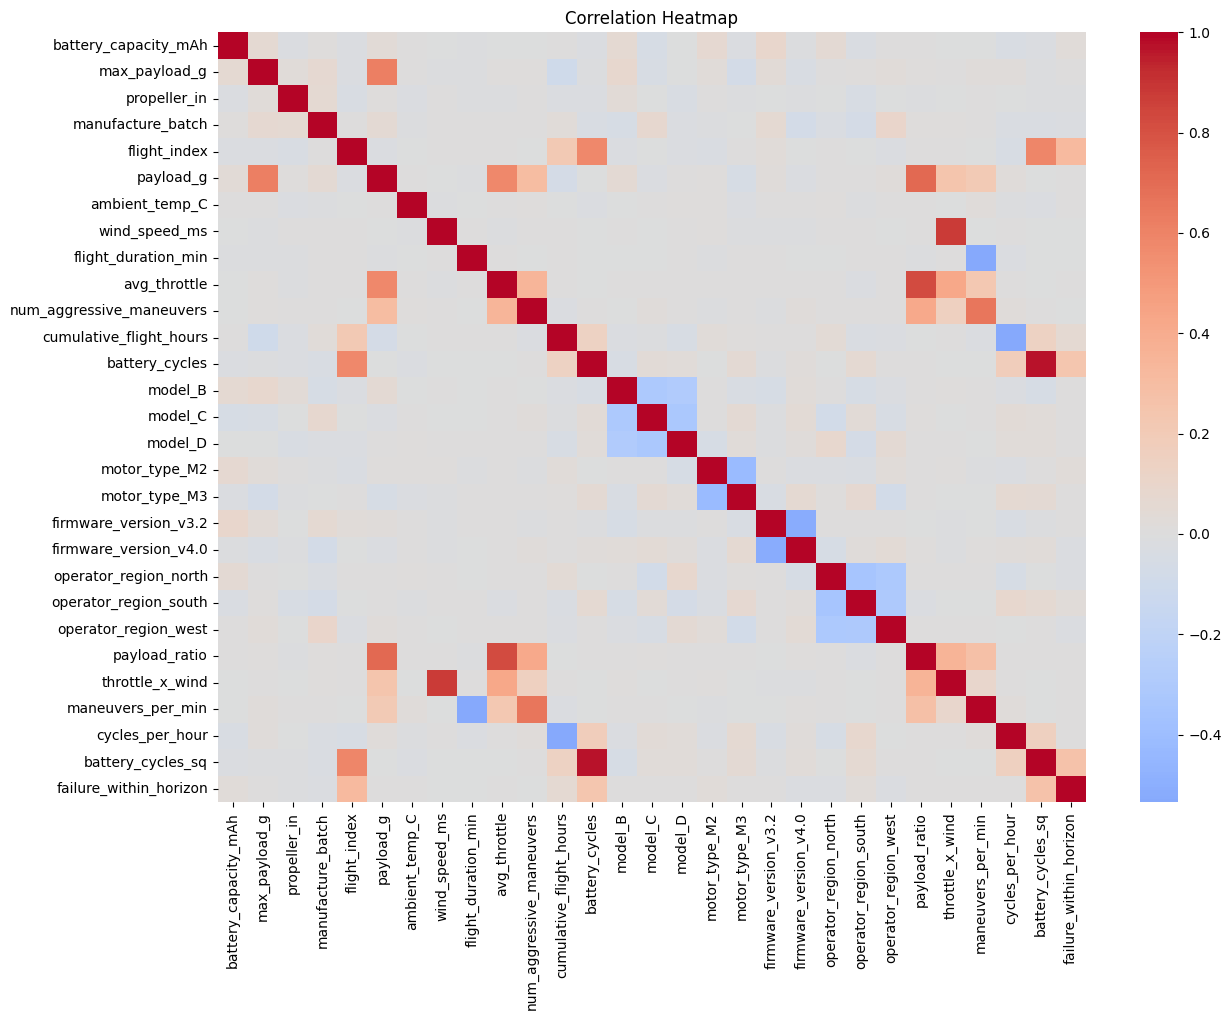

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
X_corr = pd.DataFrame(
    X_encoded,
    columns=X_encoded.columns
)
X_corr["failure_within_horizon"] = y.values
corr_matrix = X_corr.corr()

plt.figure(figsize=(14,10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

In [34]:
# Drop the parents that are causing severe multicollinearity with your engineered features
features_to_drop = [
    'battery_cycles',          # battery_cycles_sq captures this better
    'wind_speed_ms',           # throttle_x_wind captures this
    'avg_throttle',            # throttle_x_wind captures this
    'payload_g',               # payload_ratio captures this
]

X_final = X_encoded.drop(columns=features_to_drop)

In [35]:
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X_encoded)

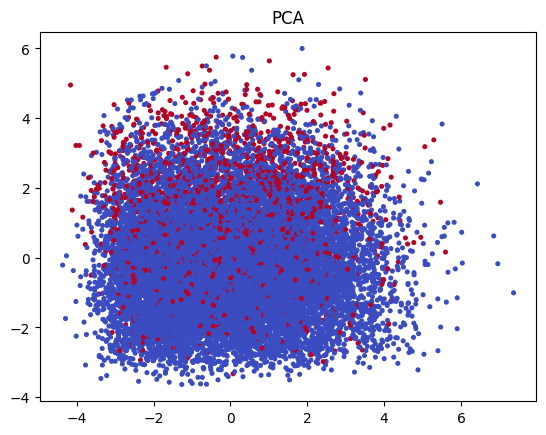

In [36]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)
plt.scatter(X_pca[:,0],X_pca[:,1],c=y,cmap="coolwarm",s=7)
plt.title("PCA")
plt.show()

In [37]:
for i in range(X_scaled.shape[1]):
    pca=PCA(n_components=i)
    X_pca=pca.fit_transform(X_scaled)
    #print(pca.explained_variance_ratio_)
    print(f"explained variance by components {i+1} {(sum(pca.explained_variance_ratio_))*100}")
    


explained variance by components 1 0
explained variance by components 2 11.188598116844256
explained variance by components 3 20.198828326159173
explained variance by components 4 26.65112344182373
explained variance by components 5 32.729497876527894
explained variance by components 6 38.48248758624767
explained variance by components 7 43.857293831530434
explained variance by components 8 49.110989840225656
explained variance by components 9 54.28447103844316
explained variance by components 10 59.14633497016343
explained variance by components 11 63.602624414573604
explained variance by components 12 67.90117397363508
explained variance by components 13 72.01033604166841
explained variance by components 14 75.65130755887274
explained variance by components 15 79.19882946492537
explained variance by components 16 82.59860313965743
explained variance by components 17 85.76569696140646
explained variance by components 18 88.7707776436888
explained variance by components 19 90.873483298

The dataset does not appear to have a single dominant direction of variation, and there is also no obvious single feature that strongly explains the target. The information seems to be distributed across multiple features. This suggest simple linear assumptions won't likely produce approriate results as the underlying predictor is much more complex than a simple linear boundary

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, GroupKFold
gkf=GroupKFold(n_splits=6)
groups = X_train["drone_id"]
lr=LogisticRegression(max_iter=1000,
    random_state=42)
scores = cross_val_score(
    lr,
    X_scaled,
    y,
    cv=gkf,
    groups=groups,
    scoring="average_precision"
)
print("Fold scores:", scores)
print("Mean AUPRC:", scores.mean())

Fold scores: [0.291439   0.38452048 0.2840564  0.33737866 0.32537557 0.33775711]
Mean AUPRC: 0.32675453447997127


Individual features exhibit weak linear correlations with the target, and low-dimensional visualizations (PCA/t-SNE) do not reveal clear class separation. However, Logistic Regression achieves strong performance (AUPRC ≈ 0.33), indicating that a linear combination of multiple features contains significant predictive information.

In [39]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_scaled, y)

coef = pd.Series(
    lr.coef_[0],
    index=X_encoded.columns
)

print(coef.sort_values(ascending=False).head(10))
print(coef.sort_values().head(10))

flight_index            0.821015
battery_cycles_sq       0.389372
motor_type_M2           0.131707
battery_capacity_mAh    0.119973
payload_ratio           0.098586
model_B                 0.093639
model_D                 0.089628
model_C                 0.078488
throttle_x_wind         0.070794
max_payload_g           0.067685
dtype: float64
firmware_version_v4.0     -0.130439
battery_cycles            -0.121256
payload_g                 -0.087292
firmware_version_v3.2     -0.076372
wind_speed_ms             -0.075789
operator_region_north     -0.074102
cumulative_flight_hours   -0.054061
manufacture_batch         -0.049514
avg_throttle              -0.048436
flight_duration_min       -0.043489
dtype: float64


In [40]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import average_precision_score

dt=DecisionTreeClassifier(random_state=42)
scores = cross_val_score(
    dt,
    X_encoded,
    y,
    cv=gkf,
    groups=groups,
    scoring="average_precision"
)
print("Fold scores:", scores)
print("Mean AUPRC:", scores.mean())


Fold scores: [0.12494687 0.13863426 0.12756199 0.16364167 0.16530242 0.15447049]
Mean AUPRC: 0.14575961538489435


In [41]:
from sklearn.ensemble import RandomForestClassifier
gkf = GroupKFold(n_splits=6)

groups = X_train["drone_id"]   

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

scores = cross_val_score(
    rf,
    X_encoded,
    y,
    cv=gkf,
    groups=groups,
    scoring="average_precision"
)

print("Fold scores:", scores)
print("Mean AUPRC:", scores.mean())

Fold scores: [0.24759074 0.36435852 0.2666977  0.3097067  0.31425173 0.30486484]
Mean AUPRC: 0.301245039143071


In [42]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_encoded, y)

importance = pd.Series(
    rf.feature_importances_,
    index=X_encoded.columns
).sort_values(ascending=False)

print(importance.head(20))

flight_index                0.104861
cycles_per_hour             0.068303
cumulative_flight_hours     0.067991
battery_cycles              0.061423
battery_cycles_sq           0.059335
ambient_temp_C              0.057340
payload_g                   0.055595
flight_duration_min         0.055027
avg_throttle                0.054158
payload_ratio               0.054130
wind_speed_ms               0.053675
throttle_x_wind             0.053655
maneuvers_per_min           0.050713
manufacture_batch           0.037499
num_aggressive_maneuvers    0.026073
propeller_in                0.019841
battery_capacity_mAh        0.019599
max_payload_g               0.018947
motor_type_M3               0.009257
firmware_version_v3.2       0.008998
dtype: float64


WHAT IS IMPORTANCE - ode Impurity: Whenever a decision tree splits a node, it uses a specific feature to separate the data into purer subsets. The drop in impurity (e.g., Gini Impurity or Variance/MSE) achieved at that node is calculated.Weighting by Samples: The drop in impurity is multiplied by the proportion of all samples that reach that specific node.Summation per Feature: For each feature, these weighted drops are summed up across all nodes in a single tree where that feature was used.Averaging Across the Forest: These scores are calculated for every single decision tree in the Random Forest and then averaged.Normalization: Finally, the scores are normalized so that all feature importances add up to 1.

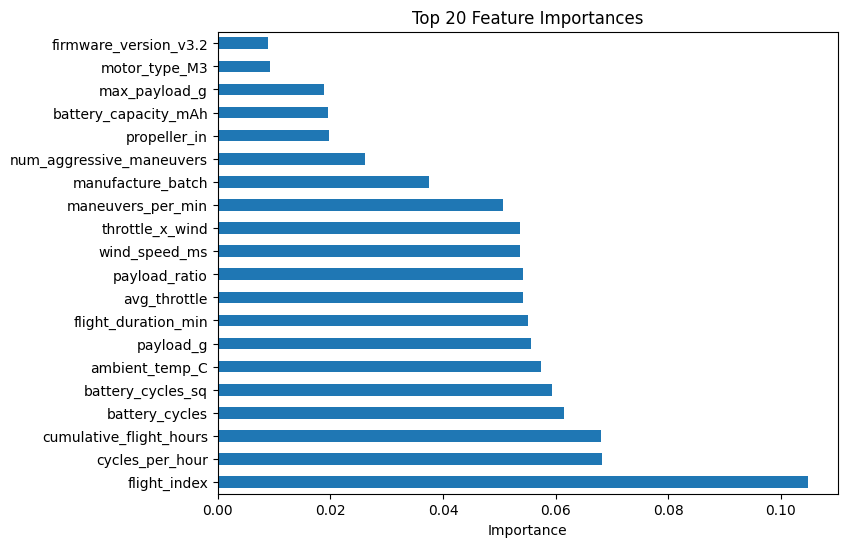

In [43]:
import matplotlib.pyplot as plt

importance.head(20).plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.show()

In [44]:
from xgboost import XGBClassifier

groups = X_train["drone_id"]
neg = (y == 0).sum()
pos = (y == 1).sum()

gkf = GroupKFold(n_splits=6)

# XGBoost model
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    scale_pos_weight=neg/pos,
    n_jobs=-1
)

scores = cross_val_score(
    xgb,
    X_encoded,
    y,
    cv=gkf,
    groups=groups,
    scoring="average_precision"      
)

print("Fold scores:", scores)
print("Mean score:", scores.mean())


Fold scores: [0.24788053 0.37752806 0.24160365 0.30492295 0.32106118 0.31970354]
Mean score: 0.30211665276884886
